In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

import scipy.cluster.hierarchy as sch
from sklearn.cluster import KMeans

# Merging the Data

In [4]:
SteamReviewsData = pd.read_csv('Data1-steam.csv')
VideoGamesData = pd.read_csv('Data2-videoGames.csv')

# print(SteamReviewsData.to_string()) 
# print(VideoGamesData.to_string()) 

VideoGamesData["match_key"] = VideoGamesData["Name"].str.strip().str.lower()
SteamReviewsData["match_key"] = SteamReviewsData["name"].str.strip().str.lower()

ColumnsSteamReviewsData = SteamReviewsData[["match_key", "genres", "positive_ratings", "negative_ratings"]].copy()

ColumnsSteamReviewsData["steam_total_reviews"] = ColumnsSteamReviewsData["positive_ratings"] + ColumnsSteamReviewsData["negative_ratings"]

ColumnsSteamReviewsData["steam_positive_review_ratio"] = ColumnsSteamReviewsData["positive_ratings"] / ColumnsSteamReviewsData["steam_total_reviews"]

ColumnsSteamReviewsData.drop(columns=["positive_ratings", "negative_ratings"], inplace=True)

MergedData = pd.merge(VideoGamesData, ColumnsSteamReviewsData, how='left', on='match_key')

MergedData.drop(columns=["match_key"], inplace=True)
MergedData.to_csv('MergedData.csv', index=False)

# print(MergedData.to_string()) 

# Cleaning and Imputation of Missing Data

### Cleaning and preparing player reviews

In [5]:
#round the steam score to 1 decimal place and scale it up so its values are betwwen 0 and 10
MergedData['steam_score'] = (MergedData['steam_positive_review_ratio'] * 10).round(1)

Producting single player score
* Scenario 1: Only User_Score available -> use it 
* Scenario 2: Only steam_score available -> use it 
* Scenario 3: Both available -> get standard weighted average 
    * I found out which kind of average I need using Gemini AI with this prompt: I have a pandas .cvs file where some of my User_Count column is low in number (max ~8,715), while my steam_total_reviews column is extremely high in number (30k+ is common). I need get to avg of User_Score and steam_score. What kind of average do i need?
        * no code was taken from  Gemini

In [6]:
#scenarios 1 and 2
rowHasSteamScore = MergedData['steam_score'].notna()
rowHasUserScore = MergedData['User_Score'].notna()

#scenario 3
MergedData['Weight_User_Count'] = np.log1p(MergedData['User_Count'])
MergedData['Weight_Steam_Reviews'] = np.log1p(MergedData['steam_total_reviews']) 

MergedData['total_u_score_weight'] = MergedData['Weight_User_Count'] + MergedData['Weight_Steam_Reviews']

# avg
scenario3 = ((MergedData['User_Score'] * MergedData['Weight_User_Count']) +  (MergedData['steam_score'] * MergedData['Weight_Steam_Reviews'])) / MergedData['total_u_score_weight']


# Apply scenarios
conditions = [
    rowHasUserScore & ~rowHasSteamScore,   # Scenario 1 
    ~rowHasUserScore & rowHasSteamScore,   # Scenario 2 
    rowHasUserScore & rowHasSteamScore ]  # Scenario 3 

choices = [
    MergedData['User_Score'], # Scenario 1 
    MergedData['steam_score'], # Scenario 2
    scenario3] # Scenario 3

# MergedData['transformed_user_score'] = np.select(conditions, choices, 0)
MergedData['transformed_user_score'] = np.select(conditions, choices, default=np.nan)


MergedData['transformed_user_score'] = (MergedData['transformed_user_score']).round(1)
MergedData = MergedData.drop(columns=['Weight_User_Count', 'Weight_Steam_Reviews', 'total_u_score_weight'])

# remove rows which don't have a final score
rows_before_Uscore_clean = len(MergedData)

rows_before = len(MergedData)
MergedData = MergedData[MergedData['transformed_user_score'].notna()]

rows_after_Uscore_clean = len(MergedData)
print(f"Number of dropped rows: {rows_before - rows_after_Uscore_clean}")
print(f"Number of remaining rows: {rows_after_Uscore_clean}")

# MergedData.to_csv('MergedData_clean.csv', index=False)

Number of dropped rows: 9364
Number of remaining rows: 8061


### Cleaning and preparing critic reviews

In [7]:

genreMedianCritic = MergedData.groupby('Genre')['Critic_Score'].transform('median')
MergedData['Critic_Score'] = MergedData['Critic_Score'].fillna(genreMedianCritic)

genreMedianCriticCunt =  MergedData.groupby('Genre')['Critic_Count'].transform('median')
MergedData['Critic_Count'] = MergedData['Critic_Count'].fillna(genreMedianCriticCunt)

MergedData = MergedData.drop(columns=['steam_positive_review_ratio', 'steam_score', 'genres', 'steam_total_reviews', 'Rating'])
MergedData.to_csv('MergedData_cleaned.csv', index=False)


### Dealing with duplicates

In [8]:
duplicatedNamesAndPlatforms = MergedData[MergedData.duplicated(subset=['Name', 'Platform'], keep=False)]
print(duplicatedNamesAndPlatforms.to_string())

rowsBeforeRemovingDuplicates = len(MergedData)
MergedData = MergedData.drop_duplicates(subset=['Name', 'Platform'], keep='first')
rowsAfterRemovingDuplicates = len(MergedData)

print(f"Number of dropped rows: {rowsBeforeRemovingDuplicates - rowsAfterRemovingDuplicates}")
print(f"Number of remaining rows: {rowsAfterRemovingDuplicates}")

                                     Name Platform  Year_of_Release       Genre           Publisher  NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales  Critic_Score  Critic_Count  User_Score  User_Count  transformed_user_score
605                         Madden NFL 13      PS3           2012.0      Sports     Electronic Arts      2.12      0.22      0.00         0.23          2.57          83.0          22.0         5.5       101.0                     5.5
776                               Mahjong      NES           1983.0        Misc            Nintendo      0.01      0.00      2.13         0.00          2.14          71.0          20.0         NaN         NaN                     7.6
777                               Mahjong      NES           1983.0        Misc            Nintendo      0.01      0.00      2.13         0.00          2.14          71.0          20.0         NaN         NaN                     6.0
1180                       SoulCalibur IV     X360           2008.0 

### Drop unneeded columns

In [9]:
MergedData = MergedData.drop(columns=['Publisher', 'Year_of_Release', 'User_Score', 'User_Count'])

### Check numeric columns and for missing values

In [10]:
print(MergedData.dtypes)

Name                       object
Platform                   object
Genre                      object
NA_Sales                  float64
EU_Sales                  float64
JP_Sales                  float64
Other_Sales               float64
Global_Sales              float64
Critic_Score              float64
Critic_Count              float64
transformed_user_score    float64
dtype: object


In [11]:
numericColumns = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Critic_Score', 'Critic_Count', 'transformed_user_score']

for col in numericColumns:
    isFullyNumeric = pd.to_numeric(MergedData[col], errors='coerce').notnull().all()
    print(f"{col}: Is only numeric => {isFullyNumeric}")

#Missing values
print(MergedData.isnull().sum())


MergedData.to_csv('Final_CA1_Data.csv', index=False)
FinalData = MergedData.copy()


NA_Sales: Is only numeric => True
EU_Sales: Is only numeric => True
JP_Sales: Is only numeric => True
Other_Sales: Is only numeric => True
Global_Sales: Is only numeric => True
Critic_Score: Is only numeric => True
Critic_Count: Is only numeric => True
transformed_user_score: Is only numeric => True
Name                      0
Platform                  0
Genre                     0
NA_Sales                  0
EU_Sales                  0
JP_Sales                  0
Other_Sales               0
Global_Sales              0
Critic_Score              0
Critic_Count              0
transformed_user_score    0
dtype: int64


# Multivariate Analysis

### Step 1 - Correlation Heatmap


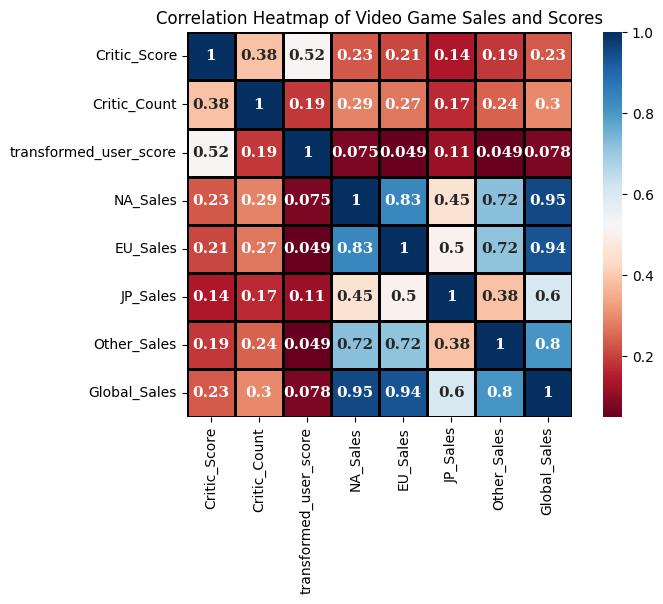

In [12]:
numeric_cols = [
    'Critic_Score', 'Critic_Count', 'transformed_user_score', 
    'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales'
]

plt.figure(figsize=(8,5))
sns.heatmap(MergedData[numeric_cols].corr(), 
             cmap='RdBu',
            square=True,
            annot=True,
              annot_kws={
                'fontsize': 11,
                'fontweight': 'bold',
                'fontfamily': 'serif',
            },
             linewidth="1",
             linecolor='black',
           );

plt.title('Correlation Heatmap of Video Game Sales and Scores')
plt.show()

### Step 2 - Normalize numerical columns


In [ ]:
#From notes:
#It is very important to scale to mean zero and standard deviation of 1 for all variables before applying PCA



# dropping the global sales column as it is a combination of the other sales columns and I expect it would dominate the PCA
numeric_cols = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales',  'Critic_Score', 'Critic_Count', 'transformed_user_score']


# Either remove or use later
print(MergedData[numeric_cols].agg(['min', 'max']))
MergedData_Normalised = MergedData.copy()
scaler = MinMaxScaler()
scaler.fit(MergedData_Normalised[numeric_cols])
MergedData_Normalised[numeric_cols] = scaler.transform(MergedData_Normalised[numeric_cols])
print(MergedData_Normalised[numeric_cols].agg(['min', 'max']))

     NA_Sales  EU_Sales  JP_Sales  Other_Sales  Critic_Score  Critic_Count  \
min      0.00      0.00       0.0         0.00          13.0           3.0   
max     41.36     28.96       6.5        10.57          98.0         113.0   

     transformed_user_score  
min                     0.0  
max                    10.0  
     NA_Sales  EU_Sales  JP_Sales  Other_Sales  Critic_Score  Critic_Count  \
min       0.0       0.0       0.0          0.0           0.0           0.0   
max       1.0       1.0       1.0          1.0           1.0           1.0   

     transformed_user_score  
min                     0.0  
max                     1.0  


### Step 3 - PCA


     NA_Sales  EU_Sales  JP_Sales  Other_Sales  Critic_Score  Critic_Count  \
min    0.0000    0.0000    0.0000         0.00          32.0           4.0   
max    3.2562    2.3808    1.0754         0.86          94.0          85.0   

     transformed_user_score  
min                     2.2  
max                     9.3  
     NA_Sales  EU_Sales  JP_Sales  Other_Sales  Critic_Score  Critic_Count  \
min    0.0000    0.0000    0.0000         0.00          32.0           4.0   
max    3.2562    2.3808    1.0754         0.86          94.0          85.0   

     transformed_user_score  
min                     2.2  
max                     9.3  


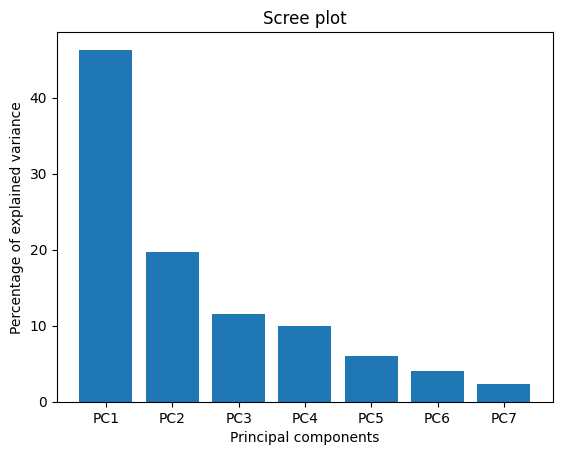

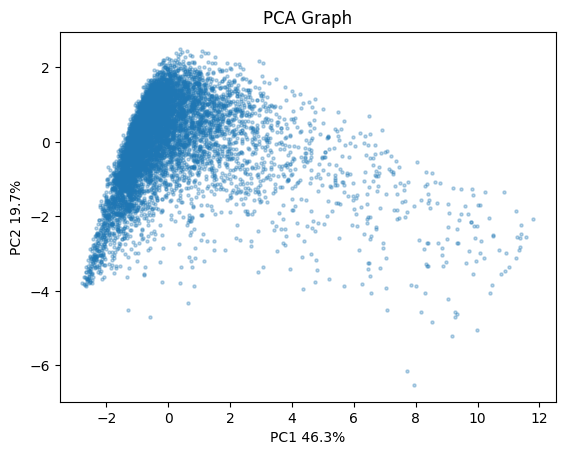

All Eigenvalues: [3.2447526  1.37939497 0.8130697  0.7025641  0.42215299 0.27788833
 0.1610473 ]

PCA1
EU_Sales                  0.481372
Other_Sales               0.478276
NA_Sales                  0.472066
Critic_Count              0.324226
Critic_Score              0.309795
JP_Sales                  0.291628
transformed_user_score    0.174769
dtype: float64

PCA2
transformed_user_score    0.685144
Critic_Score              0.555861
Other_Sales               0.270952
EU_Sales                  0.256795
Critic_Count              0.203000
NA_Sales                  0.199363
JP_Sales                  0.035820
dtype: float64
Top variables for index: ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Critic_Score']


In [ ]:
pcaScaler = StandardScaler()


scaledData = pcaScaler.fit_transform(MergedData[numeric_cols])

pca = PCA()
pca.fit(scaledData)
pca_data= pca.transform(scaledData)
per_var = np.round(pca.explained_variance_ratio_ * 100, decimals=1)

labels = ['PC'+str(i) for i in range(1, len(per_var)+1)]
plt.bar(x=range(1, len(per_var)+1), height=per_var, tick_label=labels)
plt.ylabel("Percentage of explained variance")
plt.xlabel("Principal components")
plt.title("Scree plot")
plt.show()

pca_df = pd.DataFrame(pca_data, index=MergedData['Name'], columns=labels)

plt.scatter(pca_df.PC1, pca_df.PC2, alpha=0.3, s=5)
plt.title("PCA Graph")
plt.xlabel(f'PC1 {per_var[0]}%')
plt.ylabel(f'PC2 {per_var[1]}%')
plt.show()

# Kaiser criterion says that we should retain PCs whose eigenvalue > 1
eigenvalues = pca.explained_variance_
print("All Eigenvalues:", eigenvalues)
#Therefore I'll retain PCA1, PCA2


LoadingScores = pd.Series(pca.components_[0], index=numeric_cols)
SortedLoadingScores = LoadingScores.abs().sort_values(ascending=False)
print("\nPCA1")
print(SortedLoadingScores)

LoadingScores = pd.Series(pca.components_[1], index=numeric_cols)
SortedLoadingScores = LoadingScores.abs().sort_values(ascending=False)
print("\nPCA2")
print(SortedLoadingScores)


top_vars = LoadingScores.head(5).index.tolist()
print("Top variables for index:", top_vars)
index_cols = top_vars








### Step 4 - K-Means Clustering


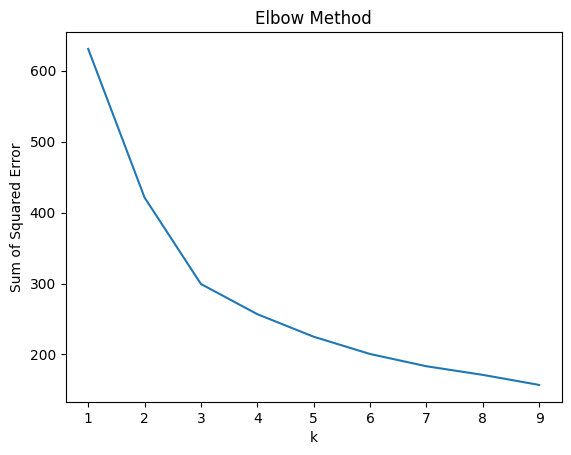

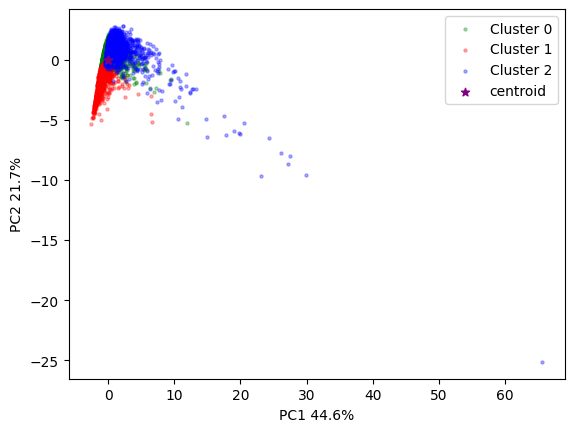

In [15]:
k_range = range(1, 10)
sse = []
for k in k_range:
    km = KMeans(n_clusters=k, n_init='auto')
    km.fit(MergedData_Normalised[numeric_cols])
    sse.append(km.inertia_)
plt.xlabel('k')
plt.ylabel('Sum of Squared Error')
plt.title('Elbow Method')
plt.plot(k_range, sse)
plt.show()


km = KMeans(n_clusters=3, n_init='auto')
pca_df['cluster'] = km.fit_predict(MergedData_Normalised[numeric_cols])

cluster0 = pca_df[pca_df.cluster == 0]
cluster1 = pca_df[pca_df.cluster == 1]
cluster2 = pca_df[pca_df.cluster == 2]

plt.scatter(cluster0.PC1, cluster0.PC2, color='green', alpha=0.3, s=5, label='Cluster 0')
plt.scatter(cluster1.PC1, cluster1.PC2, color='red', alpha=0.3, s=5, label='Cluster 1')
plt.scatter(cluster2.PC1, cluster2.PC2, color='blue', alpha=0.3, s=5, label='Cluster 2')

plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], color='purple', marker = '*', label='centroid')

plt.xlabel(f'PC1 {per_var[0]}%')
plt.ylabel(f'PC2 {per_var[1]}%')
plt.legend()
plt.show()

# Normalization

### Dealing with outliers

#### Visually display outliers

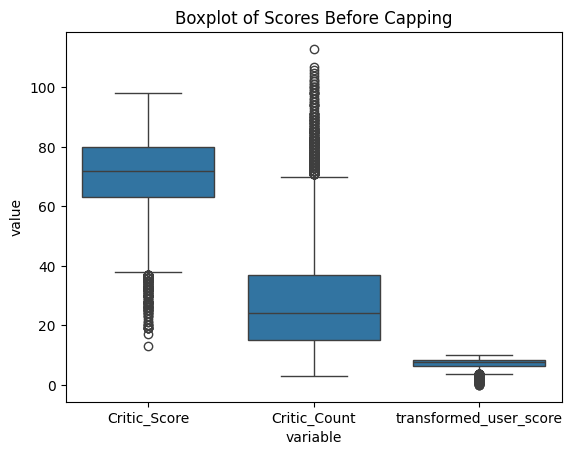

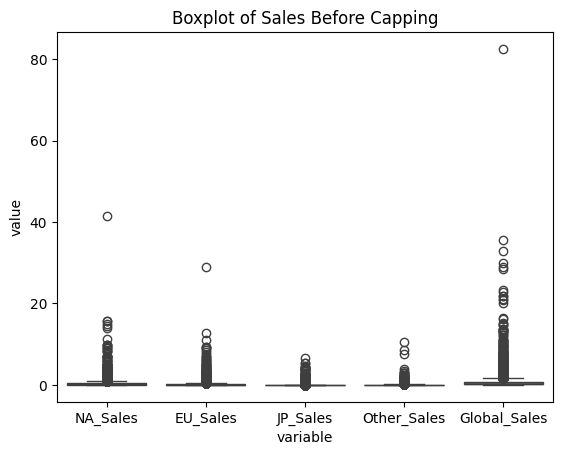

In [16]:
lower_percentile = 0.01
higher_percentile = 0.99


salesColumns = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']
scoreColumns = ['Critic_Score', 'Critic_Count', 'transformed_user_score']


sns.boxplot(x="variable", y="value", data=pd.melt(MergedData[scoreColumns]))
plt.title('Boxplot of Scores Before Capping')
plt.show()  

sns.boxplot(x="variable", y="value", data=pd.melt(MergedData[salesColumns]))
plt.title('Boxplot of Sales Before Capping')
plt.show()


MergedData.to_csv('MergedData_cleaned.csv', index=False)

#### Capping outliers

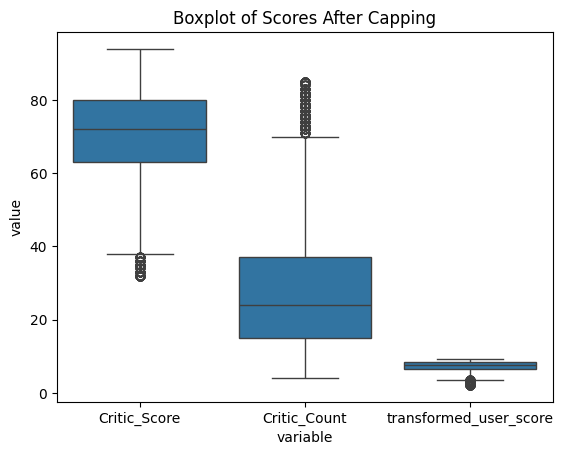

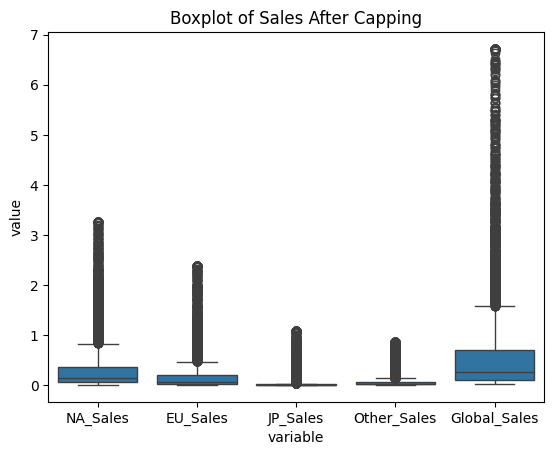

In [17]:
for column in salesColumns:
    low, high = MergedData[column].quantile([lower_percentile, higher_percentile])
    MergedData[column] = np.where(MergedData[column] > high, high, 
                         np.where(MergedData[column] < low, low, 
                         MergedData[column]))

for column in scoreColumns:
    low, high = MergedData[column].quantile([lower_percentile, higher_percentile])
    MergedData[column] = np.where(MergedData[column] > high, high, 
                         np.where(MergedData[column] < low, low, 
                         MergedData[column]))
    
sns.boxplot(x="variable", y="value", data=pd.melt(MergedData[scoreColumns]))
plt.title('Boxplot of Scores After Capping')
plt.show()  

sns.boxplot(x="variable", y="value", data=pd.melt(MergedData[salesColumns]))
plt.title('Boxplot of Sales After Capping')
plt.show()